QUESTION 1


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate synthetic data for demonstration purposes
X, y = make_blobs(n_samples=1000, n_features=4, centers=4, cluster_std=1.5, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df_data = pd.DataFrame(X_scaled, columns=feature_names)

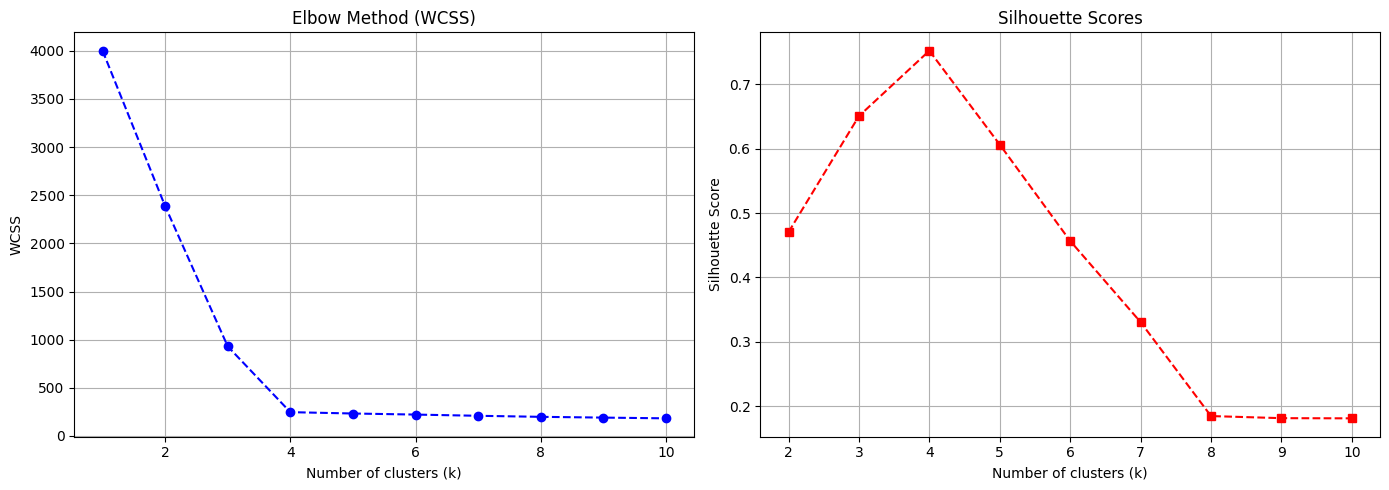

In [ ]:
def evaluate_kmeans(data, max_k=10):
    wcss = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    # For WCSS we can also calculate k=1
    wcss_all = []
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        wcss_all.append(km.inertia_)
        if k >= 2:
            wcss.append(km.inertia_)
            silhouette_scores.append(silhouette_score(data, km.labels_))

    fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    ax1[0].plot(range(1, max_k + 1), wcss_all, marker='o', color='b', linestyle='--')
    ax1[0].set_title('Elbow Method (WCSS)')
    ax1[0].set_xlabel('Number of clusters (k)')
    ax1[0].set_ylabel('WCSS')
    ax1[0].grid(True)

    # Silhouette plot
    ax1[1].plot(k_range, silhouette_scores, marker='s', color='r', linestyle='--')
    ax1[1].set_title('Silhouette Scores')
    ax1[1].set_xlabel('Number of clusters (k)')
    ax1[1].set_ylabel('Silhouette Score')
    ax1[1].grid(True)

    plt.tight_layout()
    plt.show()

evaluate_kmeans(df_data)

In [ ]:
def compare_kmeans_timing(data, k=4):
    # Standard KMeans timing
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data)
    t_km = time.time() - t0

    # MiniBatchKMeans timing
    t1 = time.time()
    mbkm = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=100, n_init=10)
    mbkm.fit(data)
    t_mbkm = time.time() - t1

    print(f"Standard KMeans Training Time: {t_km:.4f} seconds")
    print(f"MiniBatchKMeans Training Time: {t_mbkm:.4f} seconds")
    print(f"Speedup Factor: {t_km / t_mbkm:.2f}x")

compare_kmeans_timing(df_data)

Standard KMeans Training Time: 0.0147 seconds
MiniBatchKMeans Training Time: 0.0117 seconds
Speedup Factor: 1.26x


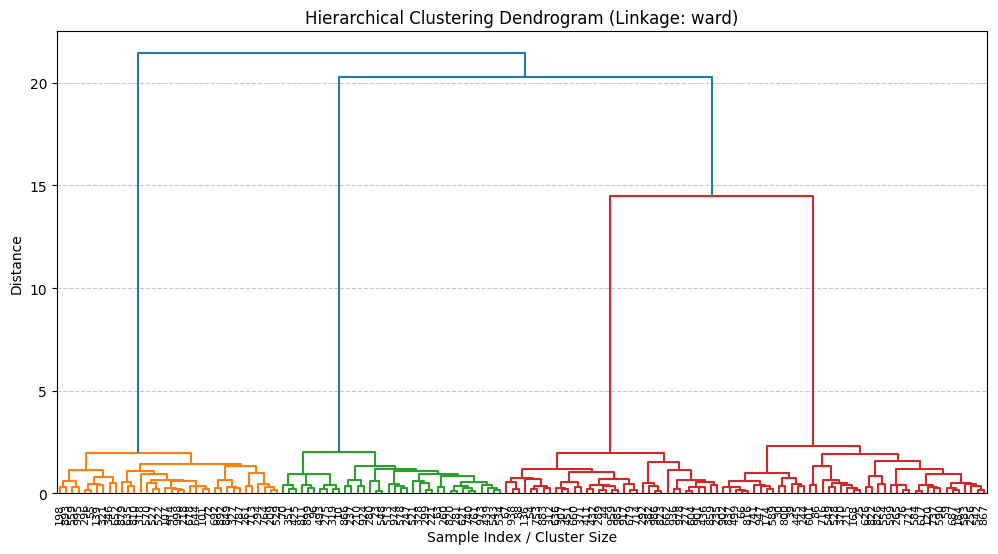

In [ ]:
def plot_hierarchical_dendrogram(data, method='ward'):
    # Subsampling to keep dendrogram clean and readable
    if len(data) > 150:
        sample_data = data.sample(n=150, random_state=42)
    else:
        sample_data = data

    Z = linkage(sample_data, method=method)

    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=sample_data.index, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'Hierarchical Clustering Dendrogram (Linkage: {method})')
    plt.xlabel('Sample Index / Cluster Size')
    plt.ylabel('Distance')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_hierarchical_dendrogram(df_data)

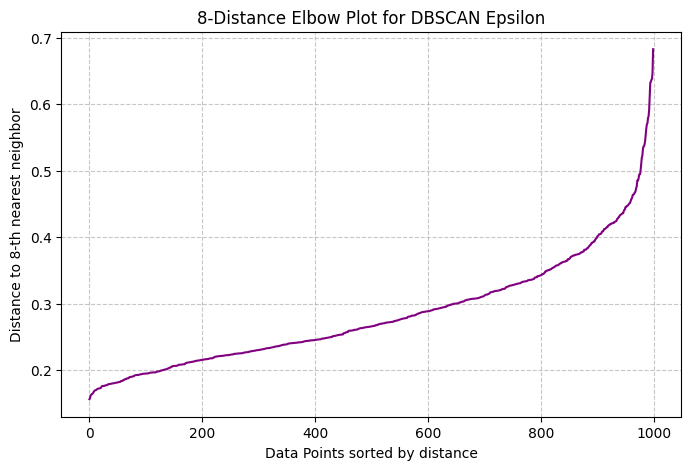

In [ ]:
def plot_k_distance(data, k=4):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)

    # Sort distances to the k-th nearest neighbor
    sorted_distances = np.sort(distances[:, k-1])

    plt.figure(figsize=(8, 5))
    plt.plot(sorted_distances, color='purple')
    plt.title(f'{k}-Distance Elbow Plot for DBSCAN Epsilon')
    plt.xlabel('Data Points sorted by distance')
    plt.ylabel(f'Distance to {k}-th nearest neighbor')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_k_distance(df_data, k=2 * df_data.shape[1])

In [ ]:
def cluster_pipeline(data, model, original_df=None):
    """
    Fits a clustering model, assigns labels to data, and returns a profiled DataFrame summary.

    Parameters:
    - data: preprocessed/scaled features (numpy array or pd.DataFrame) used for fitting
    - model: instantiated sklearn clustering object
    - original_df: (optional) dataframe with original, unscaled values for meaningful interpretation
    """
    labels = model.fit_predict(data)

    # Determine interpretation base
    interpret_df = pd.DataFrame(original_df if original_df is not None else data).copy()
    interpret_df['Cluster'] = labels

    # Calculate cluster sizes
    cluster_counts = interpret_df['Cluster'].value_counts().rename('Count')
    cluster_pcts = (interpret_df['Cluster'].value_counts(normalize=True) * 100).round(2).rename('Percentage (%)')

    # Calculate profile table (mean of variables per cluster)
    profile_means = interpret_df.groupby('Cluster').mean()

    # Combine counts, percentages, and metrics into one cohesive profile
    profile_table = pd.concat([cluster_counts, cluster_pcts, profile_means], axis=1)
    profile_table.index.name = 'Cluster ID'

    return profile_table, labels

# Demo run with KMeans
final_model = KMeans(n_clusters=4, random_state=42, n_init=10)
profile_results, labels = cluster_pipeline(df_data, final_model)

display(profile_results)

,Count,Percentage (%),feature_0,feature_1,feature_2,feature_3
Cluster ID,,,,,,
1,250,25.0,-1.267146,-1.002372,-0.629269,0.680328
2,250,25.0,-0.450259,1.291501,1.643680,-0.173680
0,250,25.0,1.314305,-0.883178,-0.254027,-1.507239
3,250,25.0,0.403100,0.594049,-0.760383,1.000592


QUESTION 2


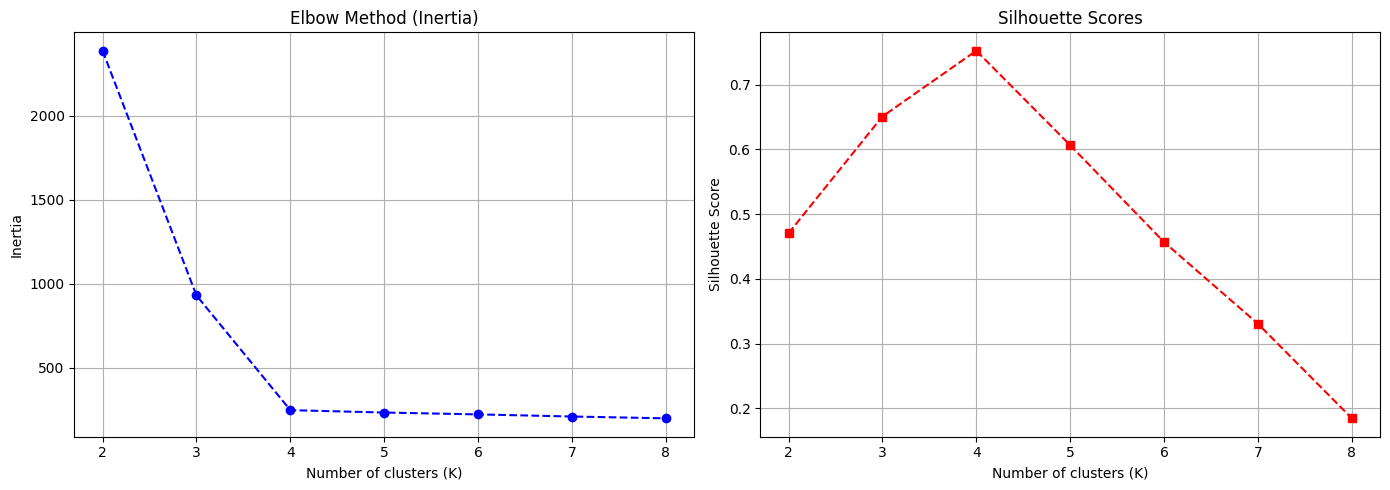

,K,inertia,silhouette
0,2,2385.432588,0.470365
1,3,929.694184,0.650678
2,4,247.439009,0.752263
3,5,233.428349,0.606383
4,6,222.272447,0.456764
5,7,209.681279,0.330617
6,8,198.822399,0.184660


In [ ]:
def cluster_pipeline(X_scaled, k_range):
    """
    Fits KMeans for each K in k_range.
    Plots inertia (elbow) and silhouette curves.
    Returns a tuple of:
      - labels_list: list of cluster labels arrays (one for each K)
      - summary_df: pandas DataFrame containing [K, inertia, silhouette]
    """
    labels_list = []
    results = []

    for k in k_range:
        # Fit KMeans
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        labels_list.append(labels)

        # Compute metrics
        inertia = km.inertia_
        sil = silhouette_score(X_scaled, labels)

        results.append({
            'K': k,
            'inertia': inertia,
            'silhouette': sil
        })

    summary_df = pd.DataFrame(results)

    # Plot curves
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    ax[0].plot(summary_df['K'], summary_df['inertia'], marker='o', color='b', linestyle='--')
    ax[0].set_title('Elbow Method (Inertia)')
    ax[0].set_xlabel('Number of clusters (K)')
    ax[0].set_ylabel('Inertia')
    ax[0].grid(True)

    # Silhouette plot
    ax[1].plot(summary_df['K'], summary_df['silhouette'], marker='s', color='r', linestyle='--')
    ax[1].set_title('Silhouette Scores')
    ax[1].set_xlabel('Number of clusters (K)')
    ax[1].set_ylabel('Silhouette Score')
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    return labels_list, summary_df

# Test execution of the new pipeline
k_range_demo = range(2, 9)
all_labels, eval_summary = cluster_pipeline(X_scaled, k_range_demo)
display(eval_summary)